# EE446 - TinyML - Assignment 2

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from pylab import rcParams
from sklearn.model_selection import train_test_split
from tensorflow.keras import datasets, layers,models
from tensorflow.keras.models import Model, load_model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Dense, Activation
from tensorflow.keras.callbacks import ModelCheckpoint, TensorBoard
from tensorflow.keras import regularizers
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score
import c_writer
from os.path import join

2026-06-03 21:59:08.737237: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-03 21:59:08.830048: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-03 21:59:09.349830: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-03 21:59:09.349950: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-03 21:59:09.351554: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

## Reading Data

In [2]:
# Reading the data and adding column header (feature) names
data = pd.read_csv("Network_anomaly_data.txt",sep=",",names=["duration","protocoltype","service",
"flag","srcbytes","dstbytes","land", "wrongfragment","urgent","hot","numfailedlogins","loggedin", "numcompromised",
"rootshell","suattempted","numroot","numfilecreations", "numshells","numaccessfiles","numoutboundcmds","ishostlogin",
"isguestlogin","count","srvcount","serrorrate", "srvserrorrate","rerrorrate","srvrerrorrate","samesrvrate",
"diffsrvrate", "srvdiffhostrate","dsthostcount","dsthostsrvcount","dsthostsamesrvrate", "dsthostdiffsrvrate",
"dsthostsamesrcportrate","dsthostsrvdiffhostrate","dsthostserrorrate","dsthostsrvserrorrate","dsthostrerrorrate",
"dsthostsrvrerrorrate","attack", "lastflag"])

In [3]:
data # printing the dataframe

,duration,protocoltype,service,flag,srcbytes,dstbytes,land,wrongfragment,urgent,hot,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20


## Question 1: Data Preprocessing

##### (a) Drop the 'land', 'urgent', 'numfailedlogins', 'numoutboundcmds' columns from the dataframe "data".

In [4]:
cols_to_drop = ['land', 'urgent', 'numfailedlogins', 'numoutboundcmds']
data = data.drop(columns=cols_to_drop)

print("Dropped columns:", cols_to_drop)
print("Modified dataframe shape:", data.shape)
data.head()

Dropped columns: ['land', 'urgent', 'numfailedlogins', 'numoutboundcmds']
Modified dataframe shape: (125973, 39)


,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


##### (b) Change any label that is not named normal to attack in the {'attack'} column of the dataframe data.

In [5]:
data['attack'] = data['attack'].apply(lambda label: 'normal' if label == 'normal' else 'attack')

print(data['attack'].value_counts())

attack
normal    67343
attack    58630
Name: count, dtype: int64


In [6]:
data #<--------- Print your modified dataframe "data"

,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,attack,19
3,0,tcp,http,SF,232,8153,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,attack,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,1,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,attack,20


##### (c) Use LabelEncoder() function from the sklearn.preprocessing library to convert non-numerical attributes in the {'protocoltype', 'service', 'flag', 'attack'} columns of the dataframe data to numerical values.

In [7]:
label_encoders = {}

for col in ['protocoltype', 'service', 'flag', 'attack']:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le
    print(f"{col} classes: {list(le.classes_)}")

print("\nEncoded dataframe preview:")
data.head()

protocoltype classes: ['icmp', 'tcp', 'udp']
service classes: ['IRC', 'X11', 'Z39_50', 'aol', 'auth', 'bgp', 'courier', 'csnet_ns', 'ctf', 'daytime', 'discard', 'domain', 'domain_u', 'echo', 'eco_i', 'ecr_i', 'efs', 'exec', 'finger', 'ftp', 'ftp_data', 'gopher', 'harvest', 'hostnames', 'http', 'http_2784', 'http_443', 'http_8001', 'imap4', 'iso_tsap', 'klogin', 'kshell', 'ldap', 'link', 'login', 'mtp', 'name', 'netbios_dgm', 'netbios_ns', 'netbios_ssn', 'netstat', 'nnsp', 'nntp', 'ntp_u', 'other', 'pm_dump', 'pop_2', 'pop_3', 'printer', 'private', 'red_i', 'remote_job', 'rje', 'shell', 'smtp', 'sql_net', 'ssh', 'sunrpc', 'supdup', 'systat', 'telnet', 'tftp_u', 'tim_i', 'time', 'urh_i', 'urp_i', 'uucp', 'uucp_path', 'vmnet', 'whois']
flag classes: ['OTH', 'REJ', 'RSTO', 'RSTOS0', 'RSTR', 'S0', 'S1', 'S2', 'S3', 'SF', 'SH']
attack classes: ['attack', 'normal']

Encoded dataframe preview:


,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,1,20,9,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,1,20
1,0,2,44,9,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,1,15
2,0,1,49,5,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0,19
3,0,1,24,9,232,8153,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,1,21
4,0,1,24,9,199,420,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1,21


In [8]:
pd.DataFrame(data) #<--------- Print your modified dataframe "data"

,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,1,20,9,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,1,20
1,0,2,44,9,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,1,15
2,0,1,49,5,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0,19
3,0,1,24,9,232,8153,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,1,21
4,0,1,24,9,199,420,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,1,49,5,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,0,20
125969,8,2,49,9,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,1,21
125970,0,1,54,9,2231,384,0,0,1,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,1,18
125971,0,1,30,5,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0,20


## Feature Scaling and Train/Test Split

In [9]:
# All the features apart from Attack are what we are going to use to predict the attack status of the data
# attack = 1 (normal/not an attack) and attack = 0 (attack)
X = data.drop(['attack'],axis=1).to_numpy()

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the data
X_normalized = scaler.fit_transform(X)

Y = data['attack'].to_numpy()
# Splitting X and y testing and training data
# we are taking 20% of the data for testing and 80% of the data for training
X_train, X_test, y_train, y_test = train_test_split(X_normalized, Y, test_size = 0.20)
# reshaping y test and train array
y_train = y_train.reshape(len(y_train),1)
y_test = y_test.reshape(len(y_test),1)

## Question 2: Dimensionality Reduction for Visualization

##### (a) Use TSNE from the sklearn.manifold library to visualize the data in the test set (X_test) in 2D. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

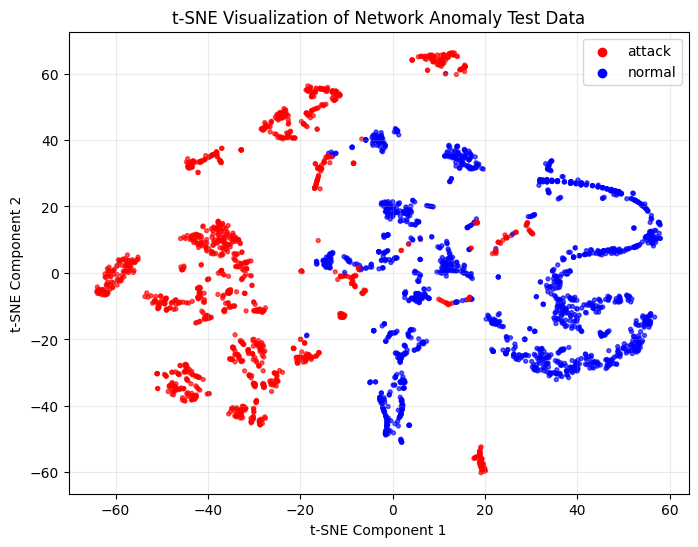

In [11]:
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

# t-SNE is very slow on the full test set, so use a representative subset for visualization.
# Red = attack, Blue = normal.

viz_size = min(3000, X_test.shape[0])
rng = np.random.default_rng(42)

viz_idx = rng.choice(X_test.shape[0], size=viz_size, replace=False)

X_viz = X_test[viz_idx]

# Make y_viz 1D so matplotlib gets a 1D color array
y_viz = np.asarray(y_test)[viz_idx].ravel()

# Assuming attack = 0 and normal = 1
colors = np.where(y_viz == 0, "red", "blue").ravel()

X_tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42,
).fit_transform(X_viz)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors, s=8, alpha=0.65)

plt.title("t-SNE Visualization of Network Anomaly Test Data")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")

# Manual legend
plt.scatter([], [], c="red", label="attack")
plt.scatter([], [], c="blue", label="normal")
plt.legend()

plt.grid(True, alpha=0.25)
plt.show()

##### (b) Use PCA from the sklearn.decomposition library to visualize the data in the test set (X_test) in 2D. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

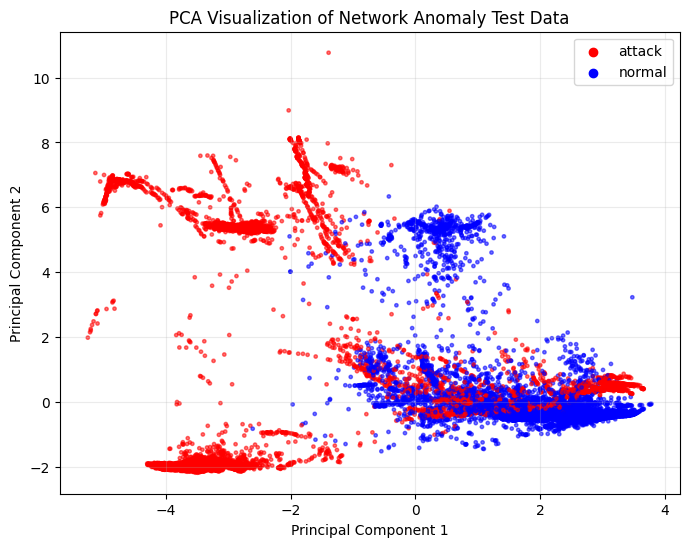

In [13]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# PCA visualization of the test set in 2D.
X_pca = PCA(
    n_components=2,
    random_state=42
).fit_transform(X_test)

# Make labels and colors 1D
y_plot = np.asarray(y_test).ravel()

# Assuming attack = 0 and normal = 1
colors = np.where(y_plot == 0, "red", "blue").ravel()

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, s=6, alpha=0.55)

plt.title("PCA Visualization of Network Anomaly Test Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.scatter([], [], c="red", label="attack")
plt.scatter([], [], c="blue", label="normal")
plt.legend()

plt.grid(True, alpha=0.25)
plt.show()

##### (c) Use KernelPCA from the sklearn.decomposition library to visualize the data in the test set (X_test) in 2D. Use radial basis function (rbf) as the kernel. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

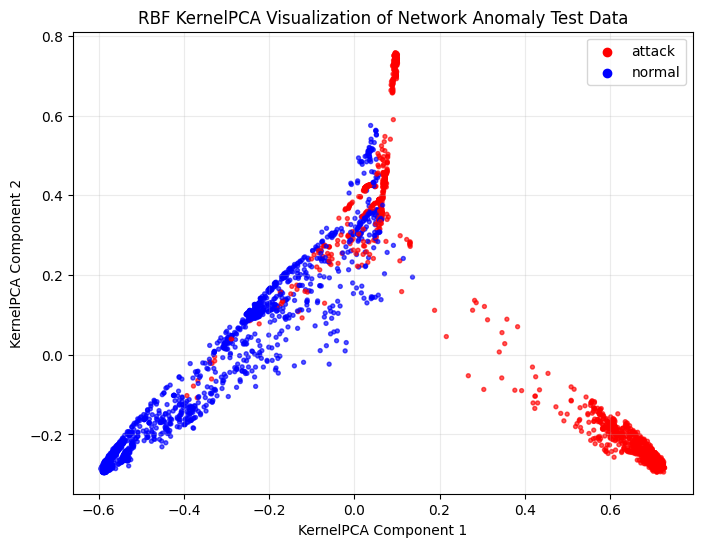

In [15]:
from sklearn.decomposition import KernelPCA
import numpy as np
import matplotlib.pyplot as plt

# KernelPCA can be memory intensive on the full test set, so use a representative subset.
viz_size = min(3000, X_test.shape[0])
rng = np.random.default_rng(42)

viz_idx = rng.choice(X_test.shape[0], size=viz_size, replace=False)

X_viz = X_test[viz_idx]

# Make labels 1D
y_viz = np.asarray(y_test)[viz_idx].ravel()

# Assuming attack = 0 and normal = 1
colors = np.where(y_viz == 0, "red", "blue").ravel()

X_kpca = KernelPCA(
    n_components=2,
    kernel="rbf",
    gamma=0.05,
    random_state=42,
).fit_transform(X_viz)

plt.figure(figsize=(8, 6))
plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=colors, s=8, alpha=0.65)

plt.title("RBF KernelPCA Visualization of Network Anomaly Test Data")
plt.xlabel("KernelPCA Component 1")
plt.ylabel("KernelPCA Component 2")

plt.scatter([], [], c="red", label="attack")
plt.scatter([], [], c="blue", label="normal")
plt.legend()

plt.grid(True, alpha=0.25)
plt.show()

## Question 3: Implementing a DNN on the dataset

##### (a) Implement a deep neural network (DNN) on the Network Anomaly Dataset. Ensure to include two neurons and softmax activation in the output layer of your DNN.

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
# Define the DNN model
base_model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.20),
    Dense(32, activation='relu'),
    Dropout(0.10),
    Dense(16, activation='relu'),
    Dense(2, activation='softmax')
])

base_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 64)                2496      
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_3 (Dense)             (None, 32)                2080      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_4 (Dense)             (None, 16)                528       
                                                                 
 dense_5 (Dense)             (None, 2)                 34        
                                                                 
Total params: 5138 (20.07 KB)
Trainable params: 5138 (20

##### (b) Compile and train your DNN model on the training set (X_train). Denote the trained model as base_model.

In [20]:
from sklearn.utils import class_weight
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

base_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Make y_train a flat 1D integer label array.
y_train_flat = np.asarray(y_train)

# If y_train is one-hot encoded, convert it back to class labels.
if y_train_flat.ndim == 2 and y_train_flat.shape[1] > 1:
    y_train_flat = np.argmax(y_train_flat, axis=1)
else:
    y_train_flat = y_train_flat.ravel()

y_train_flat = y_train_flat.astype(int)

# Class weights help account for possible class imbalance.
classes = np.unique(y_train_flat)

weights = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_flat
)

class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(classes, weights)
}

print("Class weights:", class_weights)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = base_model.fit(
    X_train,
    y_train_flat,
    validation_split=0.20,
    epochs=20,
    batch_size=256,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

print("Training complete.")

Class weights: {0: 1.0756307902489006, 1: 0.9343061633167693}
Epoch 1/20
315/315 [==============================] - 2s 4ms/step - loss: 0.0990 - accuracy: 0.9630 - val_loss: 0.0285 - val_accuracy: 0.9916
Epoch 2/20
315/315 [==============================] - 1s 3ms/step - loss: 0.0273 - accuracy: 0.9905 - val_loss: 0.0161 - val_accuracy: 0.9942
Epoch 3/20
315/315 [==============================] - 1s 3ms/step - loss: 0.0188 - accuracy: 0.9930 - val_loss: 0.0137 - val_accuracy: 0.9952
Epoch 4/20
315/315 [==============================] - 1s 4ms/step - loss: 0.0152 - accuracy: 0.9944 - val_loss: 0.0108 - val_accuracy: 0.9960
Epoch 5/20
315/315 [==============================] - 1s 4ms/step - loss: 0.0129 - accuracy: 0.9954 - val_loss: 0.0095 - val_accuracy: 0.9959
Epoch 6/20
315/315 [==============================] - 1s 4ms/step - loss: 0.0113 - accuracy: 0.9959 - val_loss: 0.0086 - val_accuracy: 0.9964
Epoch 7/20
315/315 [==============================] - 1s 4ms/step - loss: 0.0103 - acc

##### (c) Evaluate the base_model on the test set (X_test) using classification_report and confusion_matrix from the sklearn.metrics library. Report these numbers in your .pdf writeup file using screenshots.

Base model classification report:
              precision    recall  f1-score   support

      attack       1.00      1.00      1.00     11784
      normal       1.00      1.00      1.00     13411

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195

Base model confusion matrix:
[[11773    11]
 [   23 13388]]


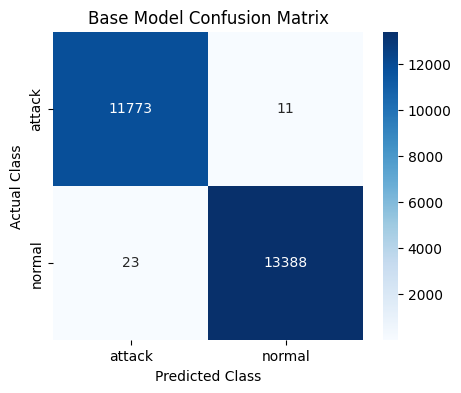

Base model test accuracy: 0.9986505258979956


In [21]:
y_prob_base = base_model.predict(X_test, verbose=0)
y_pred_base = np.argmax(y_prob_base, axis=1)

print("Base model classification report:")
print(classification_report(y_test, y_pred_base, target_names=['attack', 'normal']))

cm_base = confusion_matrix(y_test, y_pred_base)
print("Base model confusion matrix:")
print(cm_base)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_base,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['attack', 'normal'],
    yticklabels=['attack', 'normal']
)
plt.title('Base Model Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

print("Base model test accuracy:", accuracy_score(y_test, y_pred_base))

In [22]:
# Save the original Keras model to HDF5 file
base_model.save('original_model.h5')

## Question 4: Implementing Quantized Model

##### (a) Implement Dynamic Range Quantization on the base_model. Designate the resulting quantized ML model as tflite_quant_model.

In [23]:
# Load the trained model
base_model = tf.keras.models.load_model('original_model.h5')

converter = tf.lite.TFLiteConverter.from_keras_model(base_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quant_model = converter.convert()

print("Dynamic range quantization complete.")
print("Quantized model object type:", type(tflite_quant_model))
print("Quantized model size in memory:", len(tflite_quant_model) / 1024, "KB")

INFO:tensorflow:Assets written to: /tmp/tmpeizbgz9b/assets


INFO:tensorflow:Assets written to: /tmp/tmpeizbgz9b/assets


Dynamic range quantization complete.
Quantized model object type: <class 'bytes'>
Quantized model size in memory: 9.5390625 KB


2026-06-03 22:04:56.673784: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-06-03 22:04:56.673886: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-06-03 22:04:56.675444: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpeizbgz9b
2026-06-03 22:04:56.677694: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-06-03 22:04:56.677720: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpeizbgz9b
2026-06-03 22:04:56.686323: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-06-03 22:04:56.688119: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-06-03 22:04:56.766401: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpeizbgz9b
2026-06

In [24]:
import os

# Save the quantized model
with open('quantized_model.tflite', 'wb') as f:
    f.write(tflite_quant_model)

# Get the file sizes
original_model_size = os.path.getsize('original_model.h5')
quantized_model_size = os.path.getsize('quantized_model.tflite')

# Print the model sizes
print(f"Original model size: {original_model_size / 1024:.2f} KB")
print(f"Quantized model size: {quantized_model_size / 1024:.2f} KB")

Original model size: 101.62 KB
Quantized model size: 9.54 KB


##### (b) Evaluate the tflite_quant_model on the test set (X_test) using classification_report and confusion_matrix from the sklearn.metrics library. Report these numbers in your .pdf writeup file using screenshots.

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Dynamic range quantized TFLite model classification report:
              precision    recall  f1-score   support

      attack       1.00      1.00      1.00     11784
      normal       1.00      1.00      1.00     13411

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195

Dynamic range quantized TFLite model confusion matrix:
[[11773    11]
 [   23 13388]]


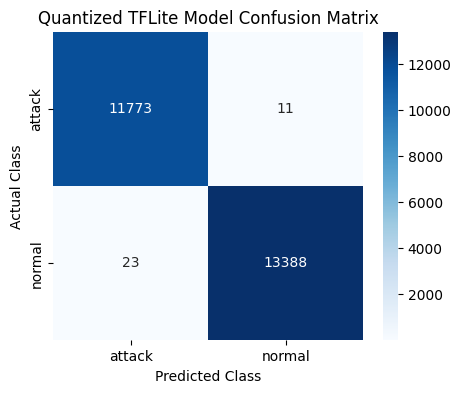

Quantized TFLite model test accuracy: 0.9986505258979956


In [25]:
def evaluate_tflite_model(tflite_model, X_eval):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    y_pred = []

    for i in range(X_eval.shape[0]):
        sample = X_eval[i:i + 1].astype(input_details['dtype'])

        interpreter.set_tensor(input_details['index'], sample)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details['index'])
        pred_class = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred_class)

    return np.array(y_pred, dtype=np.int64)


y_pred_tflite = evaluate_tflite_model(tflite_quant_model, X_test)

print("Dynamic range quantized TFLite model classification report:")
print(classification_report(y_test, y_pred_tflite, target_names=['attack', 'normal']))

cm_tflite = confusion_matrix(y_test, y_pred_tflite)
print("Dynamic range quantized TFLite model confusion matrix:")
print(cm_tflite)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_tflite,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['attack', 'normal'],
    yticklabels=['attack', 'normal']
)
plt.title('Quantized TFLite Model Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

print("Quantized TFLite model test accuracy:", accuracy_score(y_test, y_pred_tflite))

## Converting tflite_model to C and create the header file

In [26]:
# c_writer is a py file in the same folder and has been imported at the beginning of the notebook
# Reference : https://github.com/ShawnHymel/tinyml-example-anomaly-detection/blob/master/utils/c_writer.py
# We use #04x to pad the output to 2 digits with a 0x prefix
hex_array = [format(val, '#04x') for val in tflite_quant_model]
# Calling function to convert an array into a C string (requires Numpy)
# create_array(np_array, var_type, var_name, line_limit=80, indent=4)
c_model = c_writer.create_array(np.array(hex_array), 'unsigned char', "network_model")
# Calling Function to create a header file with given C code as a string
header_str = c_writer.create_header(c_model, "network_model")

In [27]:
#Writing to the header file
with open('network_model.h', 'w') as file:
    file.write(header_str)

## Generating Samples for Inference on Arduino

In [28]:
# Converting a sample piece of the X test and y test data to C (for the purpose of ino code (arduino) to load and test
# the sample and compare

Xtest = X_test[0:5,:]
print(c_writer.create_array(Xtest,"float","X_test"))

const unsigned int X_test_dim1 = 5;
const unsigned int X_test_dim2 = 38;

const float X_test[5][38] = {
    -0.11024922321249885, -0.12470615670462065, -0.6867852074966913, 
    0.7511112872365361, -0.007720505280533375, -0.004918644383724874, 
    -0.08948642202040107, -0.09507567152556495, 1.2356940323701657, 
    -0.011663642603760032, -0.036651869142258646, -0.024436507262009306, 
    0.028599260351124017, -0.02618002418454278, -0.018609896340735923, 
    -0.04122119759327531, -0.0028174939213690777, -0.0975309439715147, 
    -0.708312489286426, -0.35434285002584825, -0.6372092679572258, 
    -0.6319290328885425, -0.37436223991967527, -0.37443160310530493, 
    0.02063672680271294, 3.366063639474973, -0.37455970440553465, 
    -1.4227889618580227, -0.7104911462721373, -1.0496586099715604, 
    0.3549042915566595, -0.3183824047860378, 0.155090881452997, 
    -0.6395319051152512, -0.6248707997445304, -0.38763462350750655, 
    -0.3763870260680415, 0.6528228780141483, -0.1102492232124

In [29]:
ytest=y_test[0:5]
print(c_writer.create_array(ytest,"uint8_t","y_test"))

const unsigned int y_test_dim1 = 5;
const unsigned int y_test_dim2 = 1;

const uint8_t y_test[5][1] = {
    1, 1, 1, 1, 0
};



In [30]:
# Additional 10 samples for Arduino inference, excluding the first five samples.
Xtest_10 = X_test[5:15, :]
ytest_10 = y_test[5:15]

print("// Add this X_test array to the Arduino sketch for the 10-sample test:")
print(c_writer.create_array(Xtest_10, "float", "X_test"))

print("\n// Add this y_test array to the Arduino sketch for the 10-sample test:")
print(c_writer.create_array(ytest_10.astype(np.uint8), "uint8_t", "y_test"))

// Add this X_test array to the Arduino sketch for the 10-sample test:
const unsigned int X_test_dim1 = 10;
const unsigned int X_test_dim2 = 38;

const float X_test[10][38] = {
    0.10668259531695823, 2.219311849644404, 0.7814275260969035, 
    0.7511112872365361, -0.007737369813364, -0.004892533120637494, 
    -0.08948642202040107, -0.09507567152556495, -0.8092618187059747, 
    -0.011663642603760032, -0.036651869142258646, -0.024436507262009306, 
    -0.01238515036740332, -0.02618002418454278, -0.018609896340735923, 
    -0.04122119759327531, -0.0028174939213690777, -0.0975309439715147, 
    -0.7170454919159579, -0.35434285002584825, -0.6372092679572258, 
    -0.6319290328885425, -0.37436223991967527, -0.37443160310530493, 
    0.7712831058493207, -0.349683030873482, -0.37455970440553465, 
    0.7343425609306344, -1.0266544017850858, -1.1387558712615415, 
    2.8427159984508235, 2.432463121620216, -0.28910340026287856, 
    -0.6395319051152512, -0.6248707997445304, -0.38763462350750